# **1. 손글씨 도형**
- 손으로 그린 원, 삼각형, x 이미지를 CNN으로 분류
- 데이터 구성: 학습 데이터 240장, 테스트 60장, 3개의 클래스가 균등하게 구성

In [140]:
import torch
import random
import numpy as np
import torch.nn as nn
import torch.optim as optim
import zipfile
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from pathlib import Path

In [141]:
SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [142]:
# 압축해제
extract_dir = Path("./data")
if not extract_dir.exists():
    extract_dir.mkdir(parents=True, exist_ok=True) # data 폴더 없으면 생성
    #parents=True : ./data/shape에서 shape와 data가 없으면 상위폴더까지 생성
    #exist_ok=True : 폴더가 이미 존재하면 통과

In [143]:
with zipfile.ZipFile("./data/shape.zip", "r") as zip_ref:
    zip_ref.extractall("./data")

In [144]:
shape_root = extract_dir / 'shape'
train_dir = shape_root / 'train'
test_dir = shape_root / 'test'
print('학습 경로: ',train_dir)
print('테스트 경로: ',test_dir)

학습 경로:  data\shape\train
테스트 경로:  data\shape\test


# **2. ImageFolder**
하위 폴더 이름을 클래스 이름으로 사용하며, 알파벳 순서대로 클래스 번호를 지정함

많이 사용할 예정

In [145]:
# cir(0), tri(1), x(2)
raw_train = datasets.ImageFolder(train_dir)
raw_test = datasets.ImageFolder(test_dir)

print('클래스: ',raw_train.classes)
print('클래스 번호: ',raw_train.class_to_idx)
print('학습 데이터 이미지 수: ',len(raw_train))
print('테스트 데이터 이미지 수: ',len(raw_test))

클래스:  ['cir', 'tri', 'x']
클래스 번호:  {'cir': 0, 'tri': 1, 'x': 2}
학습 데이터 이미지 수:  240
테스트 데이터 이미지 수:  60


# **3. 전처리와 데이터 증강**
- 모든 이미지를 28*28 1채널 흑백으로 통일함
- 흰 배경에 검은 선으로 그려진 이미지를 반전하여 선 부분이 큰 값을 갖게 함
- 픽셀 값을 텐서로 바꾼 뒤, 평균을 0.5, 표준편차 0.5로 정규화
- 일반화 성능을 높이기 위해 학습 데이터에만 회전/이동/크기 등을 변화를 적용

```
검은 배경 흰 글씨가 결과가 좋음
검정이 0이라서 더 많은 픽셀이 0으로 채워져서 연산량이 적기 때문
배경이 흰색이면 1이라 연산량이 많음
```

In [146]:
# 전처리 증강
train_transform = transforms.Compose([
    # 이미지 들어올 때 ndarray형태
    transforms.Resize((28,28)),
    transforms.Grayscale(num_output_channels=1), # 이진화 형태는 아님. 명도를 줘서 밝기 정보가 존재
    transforms.RandomInvert(p=1.0), #반전 (전경 배경색 전환. 검->흰 흰->검)
    transforms.RandomAffine(degrees=12, translate=(0.08, 0.08), scale=(0.9, 1.10)), #일반화 위해 사용
    # 모델에 넣기 위해 ndarray에서 tensor로 변환
    # ToTensor(): 텐서형으로 변환,scale이 0~1 사이로 자동 정규화
    transforms.ToTensor(), #텐서로 전환
    # 중앙값을 0, 범위를 -1~1로 조절
    # x-mean / std
    # mean=(0.5,) : 튜플로 넣기 위해 ,
    # gray scale이 아닌 color면 각 채널별로 계산을 해야하기 때문에 mean=(0.5,0.5,0.5)로 채널별로 넣어야함
    transforms.Normalize(mean=(0.5,),std=(0.5,)) # 평균 0.5 표준편차 0.5
])

# 검증
eval_transform = transforms.Compose([
    transforms.Resize((28,28)),
    transforms.Grayscale(num_output_channels=1),
    transforms.RandomInvert(p=1.0),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,),std=(0.5,))
])


# **4. 학습/검증/테스트 데이터 분리**
- 학습 데이터: 가중치를 실제로 업데이트
- 검증 데이터: 학습 중 모델 선택과 과적합 확인에 사용
- 테스트 데이터: 모든 학습과 모델 선택이 끝난 뒤, 최종 성능을 확인

In [147]:
base_dataset = datasets.ImageFolder(train_dir)
class_names = base_dataset.classes
num_classes = len(class_names)
num_classes

3

In [148]:
print(base_dataset.targets)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


In [149]:
np.array(base_dataset.targets) == 0

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

In [150]:
train_indices = []
val_indicies = []
rng = np.random.default_rng(SEED)

for class_idx in range(num_classes):
    indices = np.where(np.array(base_dataset.targets) == class_idx)[0] # 참인 경우의 idx만 뽑음
    rng.shuffle(indices) # 숫자를 섞음
    split = int(len(indices)*0.8) # 80%를 split에 저장
    train_indices.extend(indices[:split].tolist())
    val_indicies.extend(indices[split:].tolist())

train_full = datasets.ImageFolder(train_dir, transform=train_transform) # transform은 데이터를 꺼낼 때 행해짐
val_full = datasets.ImageFolder(train_dir, transform=eval_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=eval_transform)

# 기존 데이터셋에서 원하는 데이터만 선택하여 새로운 데이터셋을 생성
train_dataset = Subset(train_full, train_indices) # train_full에서 train_indices즉 80%만 뽑아서 저장
val_dataset = Subset(val_full, val_indicies)

print('학습: ', len(train_dataset))
print('검증: ', len(val_dataset))
print('테스트: ', len(test_dataset))

학습:  192
검증:  48
테스트:  60


In [151]:
BATCH_SIZE = 32

# pin_memory=True
# CPU의 일반적인 메모리를 Pageable Memory라고 하고, GPU 전송에 유리하도록 고정된 CPU 메모리를 Pinned Memory라고 함

# 한 번에 32개씩 데이터 가져옴. 그 때마다 인덱싱이 일어나며 transform 발생
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True) # 0은 모두 활용, -1은 최대한 적게 활용
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# **5. 이미지와 텐서 모양 확인**

- CNN 입력 텐서: [배치, 채널, 높이, 너비]
- 현재 데이터의 배치 shape: [32, 1, 28, 28]

In [152]:
images, labels = next(iter(train_loader))
print('이미지 배치: ', images.shape)
print('레이블 배치: ', labels.shape)

이미지 배치:  torch.Size([32, 1, 28, 28])
레이블 배치:  torch.Size([32])


In [153]:
def denormalize(image):
    # 정규화 돌려놓기
    return image*0.5 + 0.5

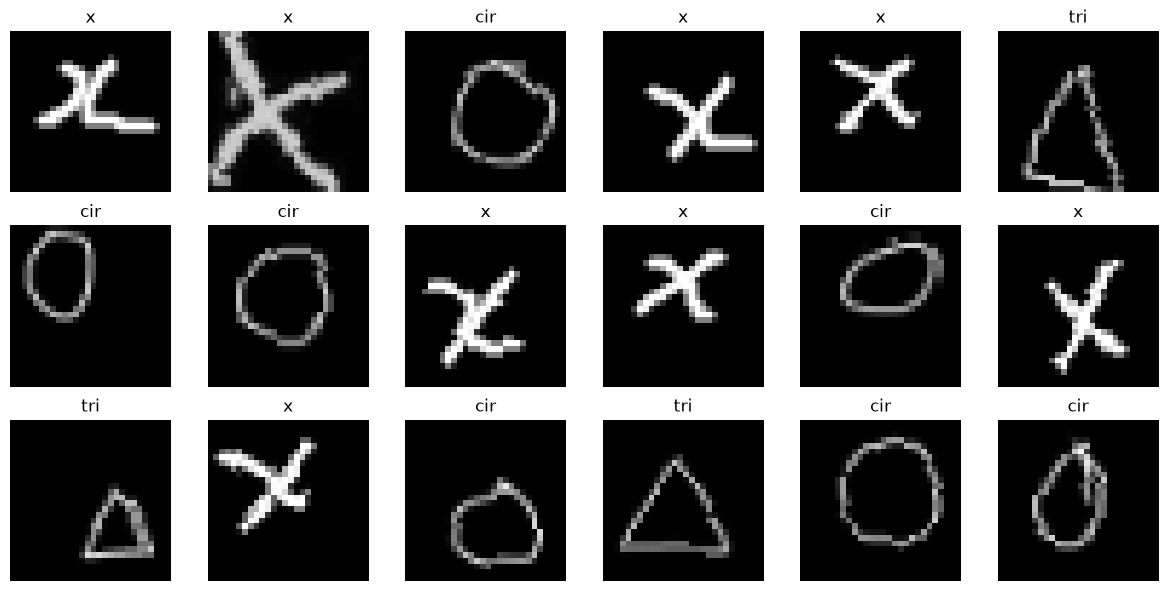

In [154]:
fig, axes = plt.subplots(3, 6, figsize=(12, 6))
for ax, image, label in zip(axes.flat, images[:18], labels[:18]):
    ax.imshow(denormalize(image).squeeze(0), cmap='gray', vmin=0, vmax=1)
    ax.set_title(class_names[label.item()])
    ax.axis('off')
plt.tight_layout()
plt.show()

# **6. CNN 모델**

### BatchNorma2d
CNN이 학습하면서 만들어낸 각 채널(feature map)의 값들을 적절한 범위로 정규화해서 학습을 더 안정적으로 만들어주는 층

데이터를 넘기기 전에 정규화해서 정리하기 위함

```
입력 이미지 > Conv2d > 32개의 Feature Map 생성 > BatchNorm2d > 각 Feature Map의 값들을 정규화 > ReLU
nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False),
nn.BatchNorm2d(32), #채널 수
nn.ReLU()
```

> CNN의 Conv2d를 통과하면 값들이 여러가지로 변함. 처음 입력 이미지가 어느 정도 정규화되어 있어도 Conv2d를 통과하고 나면 가중치와 계산되면서 "채널마다" 값의 분포가 달라질 수 있음. BatchNormalization은 값을 어느 정도 정돈해서 다음층으로 보내주는 역할을 함. !각 채널별 정규화가 필요함

### AdaptiveAvgPool2d
- 입력 이미지의 크기가 얼마이든 상관없이 최종 출력 크기를 항상 특정 크기로 만들어주는 평균 풀링 레이어
- CNN에서 분류 모델의 마지막 부분에 자주 사용

```
nn.AvgPool2d(kernel_size=2)

# feature map
1 3 2 4
5 7 6 8
2 4 1 3
6 8 5 7

2*2의 평균을 계산 > (1+3+5+7)/4=4

nn.AdaptiveAvgPool2d((1,1))
입력 크기가 어떻게 생겼든 최종적으로 1*1로 만들어줘!

1 2
3 4

(1+2+3+4)/4 = 2.5
Feature Map 하나를 대표하는 값 하나가 만들어짐
```

```
예) Conv2d를 통과해서 Feature Map이 64개일 경우
[32, 64, 14, 14] #batch size, feautre map size, img height, img width

nn.AdaptiveAvgPool2d((1,1))
[32, 64, 1, 1]
```

> 채널 개수는 그대로 유지되고 H, W만 줄어듬


### Dropout
- 신경망이 학습할 때 일부 뉴런을 일부러 랜덤하게 꺼버리는 기법
- 과적합을 줄이기 위해 사용
- 네트워크에서 뉴런을 영구적으로 삭제하는 것이 아니며, 학습 순간에만 뉴런의 출력을 0으로 함 (이번 학습에만 안쓰는 것으로, 다음 학습에서 쓸 수 있음)
- model.train()시 Dropout 작동, model.eval() Dropout 꺼짐

In [155]:
class ShapeCNN(nn.Module):
    # 파이토치에서 제공하는 모듈 메서드 사용 위한 상속
    
    def __init__(self, num_classes=3):
        super().__init__() # 부모 생성자 호출

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1, bias=False), #grey scale : 1, kernel num:32,
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True), #기본값 fasle. # inplace=True : ReLU 계산결과를 덮어쓰라는 옵션. 기존 텐서 값을 변경해 메모리를 아낄 수 있음.
            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            # BatchNorm에서 넘어온 Tensor를 별도의 새로운 Tensor로 복사해서 처리하지 말고, Tensor의 메모리를 직접 수정하여 메모리를 절약
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2), #default : 2
            # 모두 통과하는 층이라 모두 커널 크기 필요


            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64), # 채널별로 정규화시켜야 하기 때문
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(), # 이미지 일렬로 핌
            nn.Dropout(p=0.25),
            nn.Linear(64,num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [156]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')

elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')

elif torch.xpu.is_available():
    DEVICE = torch.device('xpu')

else:
    DEVICE = torch.device('cpu')

print(DEVICE)

cpu


In [157]:
model = ShapeCNN(num_classes=num_classes).to(DEVICE)
model

ShapeCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2

In [158]:
criterion = nn.CrossEntropyLoss()

### AdamW
- Adam에 가중치 감쇠(Weight Decay)를 적용한 방식
- 딥러닝 모델의 가중치가 지나치게 커지면 학습 데이터에 너무 맞춰지는 과적합이 발생할 수 있음 > Weight Decay로 학습 중에 가중치를 조금씩 줄여서 너무 커지지 않도록 하는 방법을 사용
- 과적합을 줄이고 일반화 성능을 높이도록 만듬

```
Gradient > Adam의 적응적 계산 > 가중치 업데이트 > Weight Decay를 적용(안에 L2 규제 포함됨)
```

In [159]:
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

### Scheduler
- 검증 성능이 더 이상 좋아지지 않을 때 자동으로 학습률을 낮춰주는 기능
- 가중치 = 가중치 - 학습률 * 기울기

loss를 최대한 줄이기 위해 조금씩이라도 더 낮춰 촘촘하게 이동하기 위해서

```
Epoch1 Loss: 0.8
Epoch2 Loss: 0.6
Epoch3 Loss: 0.5
Epoch4 Loss: 0.43
Epoch5 Loss: 0.40 # 이후로 Loss가 좋아지지 않음
Epoch6 Loss: 0.41
Epoch7 Loss: 0.42
Epoch8 Loss: 0.41
```

- mode: 무엇을 기준으로 좋아졌다고 판단할지를 결정
- factor: 학습률 반영값 (예: factor=0.5 기존 학습률을 절반 반영)
- patience: 몇 번까지 참아줄 것인지 설정 (몇 번까지 기다려줄지)

In [160]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau( #Plateau: 정체 # 학습률이 정체되었을 때 감소시키는 함수
    optimizer, mode='min', factor=0.5, patience=3    
)

### 학습과 평가 함수

In [161]:
def run_epoch(model, loader, criterion, device, optimizer=None): # for문 안에 들어갈 함수
    is_training = optimizer is not None
    # model.train()
    # 모델이 학습 형태로 동작. optimizer를 메모리에 올림. train에 필요한 것들을 메모리에 올림
    model.train() if is_training else model.eval() #학습중이 아니면 optimizer,dropout 끈 eval 사용
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    # enable_grad: 기울기 계산을 활성화
    # 기본값으로 grad가 되어있음
    # inference_mode(): 메모리 사용량 감소. 불필요한 기울기 계산 방지. 실행 속도 향상
    context = torch.enable_grad() if is_training else torch.inference_mode()
    with context:
        for images, labels in loader:
            images = images.to(device, non_blocking=True) # 이미지 옮기는데 시간이 걸림. 
            #non_blocking=True: 기다리지 말고 받을 때 바로 연산을 하는 옵션
            #dataloader에서 pin_memory=True 설정 해줘야 쓸 수 있음
            labels = labels.to(device, non_blocking=True)

            if is_training:
                # set_to_none=True: 기울기 값을 0으로 채우는 대신 None으로 설정
                # 메모리 사용을 줄일 수 있음. 불필요한 0 텐서 생성을 줄임
                optimizer.zero_grad(set_to_none=True)

            model = model.to(device)
            logits = model(images)
            loss = criterion(logits, labels)

            if is_training:
                loss.backward()
                optimizer.step()

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples

### 모델 학습과 Early Stopping
- 검증 손실이 가장 낮을 때의 가중치를 저장
- 일정 횟수 동안 검증 손실이 개선되지 않으면 학습을 조기에 종료하여 과적합과 불필요한 학습을 줄임

In [162]:
EPOCHS = 50
EARLY_STOPPING_PATIENCE = 8 #8번 정도 좋아지지 않으면 그만두기
best_val_loss = float('inf') # float형 무한대
wait = 0
history = {'train_loss':[], 'val_loss':[], 'train_acc':[],'val_acc':[]}
best_model_path = 'best_shape_cnn.pth'

In [163]:
for epoch in range(1, EPOCHS+1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, DEVICE, optimizer)
    # 학습이 아니라 optimizer 불필요
    val_loss, val_acc = run_epoch(model, val_loader, criterion, DEVICE)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    current_lr = optimizer.param_groups[0]['lr'] # param_groups에 학습중인 모델 lr이 저장됨

    print(
        f'Epoch {epoch:02d}/{EPOCHS} | '
        f'train loss {train_loss:.4f}, acc {train_acc*100:6.2f}% | '
        f'val loss {val_loss:.4f}, acc {val_acc*100:6.2f}% | '
        f'lr {current_lr:.6f}'
    )

    # 가중치 저장
    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        wait = 0 # loss가 더 낮아졌기 때문에 기다리지 않았다는 의미
        torch.save(model.state_dict(),best_model_path)

    else:
        wait += 1
        if wait >= EARLY_STOPPING_PATIENCE:
            print('검증 손실이 더 이상 개선되지 않아 학습을 종료합니다.')
            break



Epoch 01/50 | train loss 0.8001, acc  59.38% | val loss 1.0509, acc  35.42% | lr 0.001000
Epoch 02/50 | train loss 0.5655, acc  72.92% | val loss 0.8812, acc  64.58% | lr 0.001000
Epoch 03/50 | train loss 0.5394, acc  71.88% | val loss 0.7471, acc  66.67% | lr 0.001000
Epoch 04/50 | train loss 0.4697, acc  80.73% | val loss 0.6648, acc  77.08% | lr 0.001000
Epoch 05/50 | train loss 0.4643, acc  83.33% | val loss 0.6376, acc  83.33% | lr 0.001000
Epoch 06/50 | train loss 0.4359, acc  82.81% | val loss 0.4986, acc  83.33% | lr 0.001000
Epoch 07/50 | train loss 0.3767, acc  85.94% | val loss 0.5551, acc  85.42% | lr 0.001000
Epoch 08/50 | train loss 0.3566, acc  85.94% | val loss 0.3946, acc  87.50% | lr 0.001000
Epoch 09/50 | train loss 0.3821, acc  83.85% | val loss 0.4624, acc  72.92% | lr 0.001000
Epoch 10/50 | train loss 0.3213, acc  90.62% | val loss 0.4422, acc  70.83% | lr 0.001000
Epoch 11/50 | train loss 0.3128, acc  91.15% | val loss 0.4440, acc  75.00% | lr 0.001000
Epoch 12/5

# **7. 학습 곡선으로 과적합 확인**
- 학습 손실과 검증 손실이 함께 감소하면 정상적인 학습에 가까움
- 학습 손실은 계속 감소하지만, 검증 손실이 증가하면 과적합 가능성이 큼
- 학습/검증 정확도가 모두 낮으면 모델 용량, 전처리, 학습률, 데이터  품질 등을 점검해야 함 

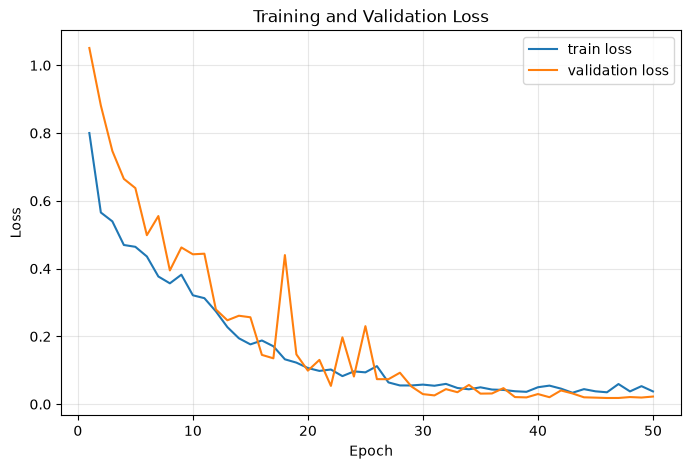

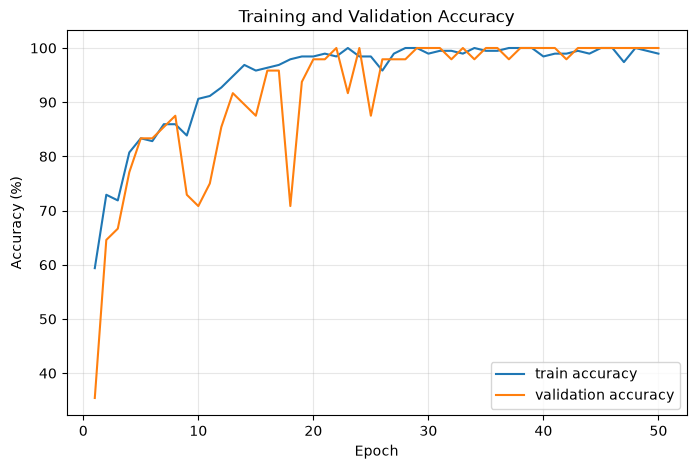

In [164]:
epochs_ran = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history['train_loss'], label='train loss')
plt.plot(epochs_ran, history['val_loss'], label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, np.array(history['train_acc']) * 100, label='train accuracy')
plt.plot(epochs_ran, np.array(history['val_acc']) * 100, label='validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# **8. 학습된 모델로 테스트 평가**
### 학습되지 않은 모델로 테스트 평가

In [165]:
model = ShapeCNN(num_classes=num_classes).to(DEVICE)
model

ShapeCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2

In [166]:
test_loss, test_acc = run_epoch(model, test_loader, criterion, DEVICE)
print(f'테스트 Loss: {test_loss:.4f}')
print(f'테스트 acc: {test_acc*100:.2f}')

테스트 Loss: 1.1024
테스트 acc: 33.33


### 가중치를 불러와 모델에 적용한 후 테스트 평가

In [167]:
model = ShapeCNN(num_classes).to(DEVICE)
model.load_state_dict(torch.load(best_model_path,map_location=DEVICE,weights_only=True))

<All keys matched successfully>

In [168]:
test_loss, test_acc = run_epoch(model, test_loader, criterion, DEVICE)
print(f'테스트 Loss: {test_loss:.4f}')
print(f'테스트 acc: {test_acc*100:.2f}')

테스트 Loss: 0.0422
테스트 acc: 98.33


# **9. 혼동행렬과 클래스별 성능**
- 전체 정확도가 높아도 특정 클래스만 자주 틀릴 수 있음
- 혼동행렬은 실제 클래스와 예측 클래스의 조합을 볼 수 있음
- 대각선 값이 클수록 올바르게 분류한 이미지가 많다는 뜻

In [169]:
def collect_predictions(model, loader):
    model.eval()
    all_images = []
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.inference_mode():
        for images, labels in loader:
            logits = model(images.to(DEVICE))
            probs = torch.softmax(logits, dim=1).cpu()
            preds = probs.argmax(dim=1)

            all_images.append(images.cpu())
            all_labels.append(labels.cpu())
            all_preds.append(preds)
            all_probs.append(probs)

    return (
        torch.cat(all_images),
        torch.cat(all_labels),
        torch.cat(all_preds),
        torch.cat(all_probs),
    )

In [170]:
test_images, y_true, y_pred, y_prob = collect_predictions(model, test_loader)

In [171]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

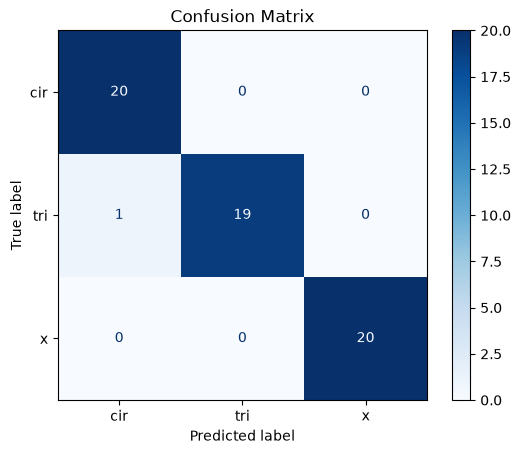

In [172]:
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
display.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

In [173]:
print(classification_report( # print로 찍어야 이쁘게 나옴
    y_true.numpy(),
    y_pred.numpy(),
    target_names=class_names,
    digits=4,
    zero_division=0, # 0으로 나누는 계산은 그냥 0으로
))

              precision    recall  f1-score   support

         cir     0.9524    1.0000    0.9756        20
         tri     1.0000    0.9500    0.9744        20
           x     1.0000    1.0000    1.0000        20

    accuracy                         0.9833        60
   macro avg     0.9841    0.9833    0.9833        60
weighted avg     0.9841    0.9833    0.9833        60



# **10. 오분류 이미지 분석**
- 모델이 틀린 이미지에는 데이터 품질, 모호한 이미지, 전처리 문제, 부족한 학습 데이터 등 중요한 단서가 들어가 있음
- 단순히 정확도만 보는 것보다 오분류 사례를 직접 확인하는 것이 모델 개선에 매우 중요

In [174]:
wrong_indices = torch.where(y_true != y_pred)[0]
print('오분류 이미지 수: ', len(wrong_indices))

오분류 이미지 수:  1


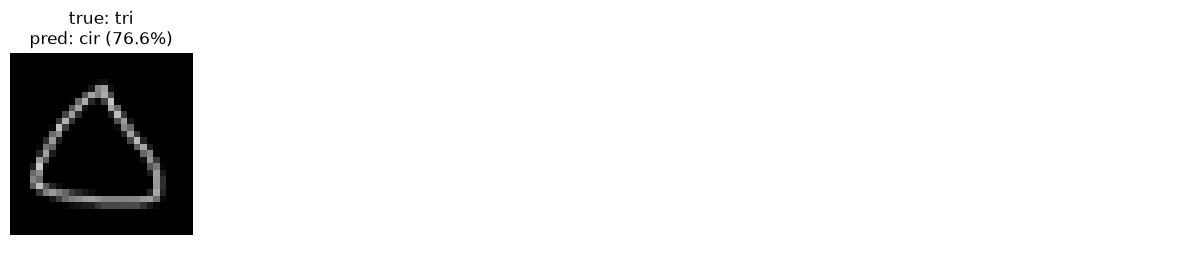

In [175]:
if len(wrong_indices) == 0:
    print('현재 테스트 데이터에서 오분류 이미지가 없습니다.')
else:
    show_count = min(18, len(wrong_indices))
    selected = wrong_indices[:show_count]
    rows = int(np.ceil(show_count / 6))
    fig, axes = plt.subplots(rows, 6, figsize=(12, 2.5 * rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis('off')

    for ax, idx in zip(axes, selected):
        true_idx = y_true[idx].item()
        pred_idx = y_pred[idx].item()
        confidence = y_prob[idx, pred_idx].item() * 100
        ax.imshow(denormalize(test_images[idx]).squeeze(0), cmap='gray', vmin=0, vmax=1)
        ax.set_title(
            f'true: {class_names[true_idx]}\n'
            f'pred: {class_names[pred_idx]} ({confidence:.1f}%)'
        )
        ax.axis('off')

    plt.tight_layout()
    plt.show()

### 성능을 더 높일 때 점검할 순서

1. 잘못된 레이블이나 지나치게 모호한 그림이 없는지 확인
2. 실제 사용 환경과 학습 데이터의 배경색 / 선 굵기 / 크기 차이를 줄임
3. 클래스별 데이터를 더 다양하게 수집
4. 증강 강도를 조금씩 바꿔 검증 성능을 비교
5. 데이터가 충분히 늘어난 뒤 모델 크기와 학습률을 조절

> 이 데이터는 전체 300장으로 매우 작음. 테스트 정확도가 높더라도 실제 손글씨 전체를 대표한다고 단정할 수 없음. 새로운 사람이 그린 별도의 데이터도 추가 검증해야 함